<a href="https://colab.research.google.com/github/DD-Bin/Dede-Bintang-Gafendi_2411533010_ML2526/blob/main/Praktikum2/GaussianNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set_style("darkgrid")

In [14]:
dataset_url = 'https://raw.githubusercontent.com/DD-Bin/Dede-Bintang-Gafendi_2411533010_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv'
data = pd.read_csv(dataset_url)
data.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


<Axes: >

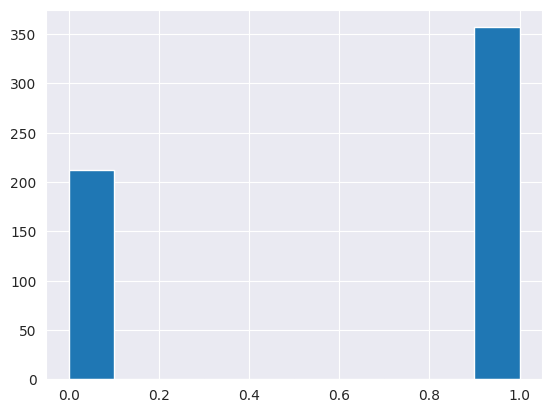

In [16]:
data["diagnosis"].hist()

<Axes: >

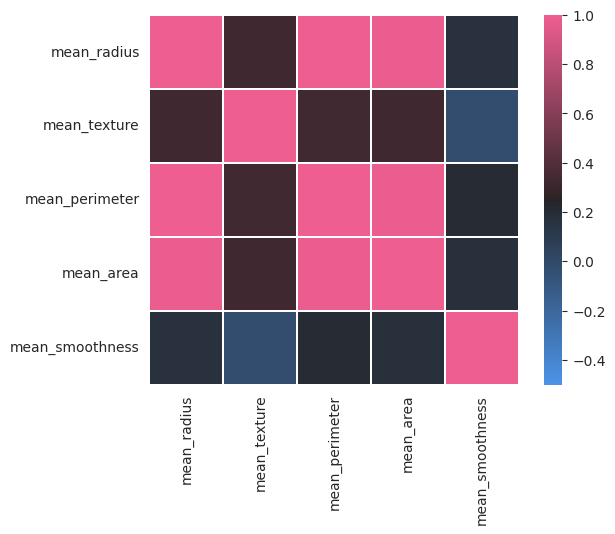

In [20]:
corr = data. iloc[:,:- 1].corr(method="pearson")
cmap = sns.diverging_palette(250,354,80,60, center='dark', as_cmap=True)
sns.heatmap(corr, vmax=1, vmin =-.5, cmap=cmap, square=True, linewidths =.2)

<Axes: xlabel='mean_texture', ylabel='Count'>

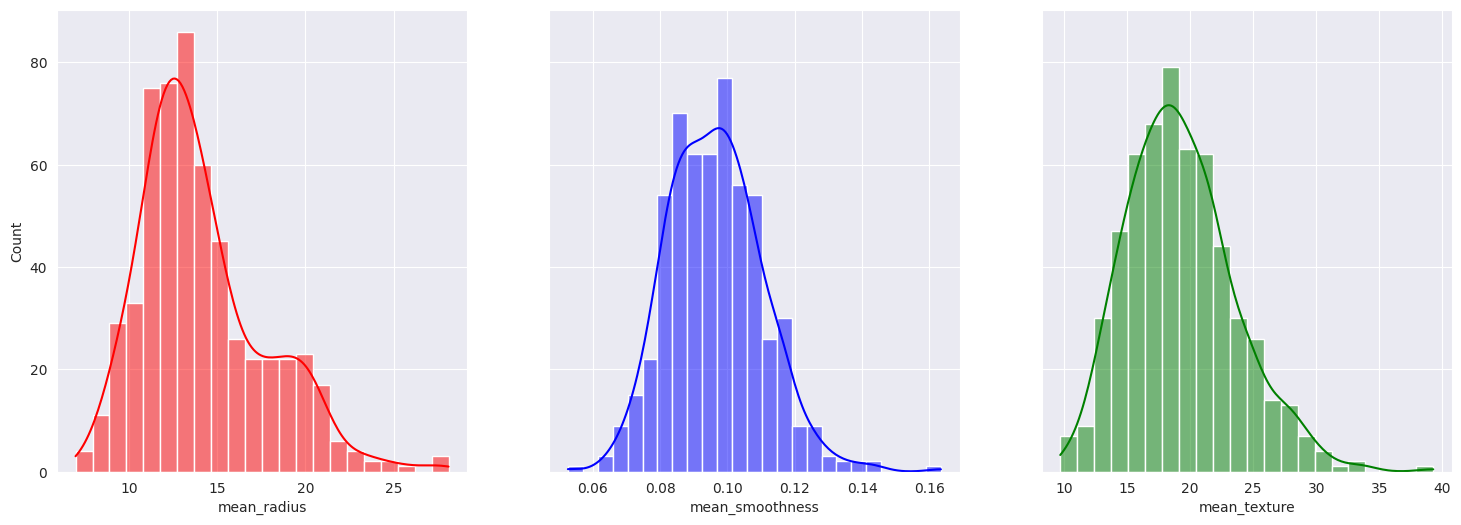

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
sns.histplot(data, ax=axes [0], x="mean_radius", kde=True, color='r' )
sns.histplot(data, ax=axes[1], x="mean_smoothness", kde=True, color='b')
sns.histplot(data, ax=axes[2], x="mean_texture", kde=True, color='g')

In [29]:
def calculate_prior(df, Y):
    classes = sorted(list(df [Y]. unique( ) ) )
    prior = []
    for i in classes:
      prior.append(len(df[df[Y] == i])/len(df))
    return prior

In [46]:
def calculate_likelihood_gaussian(df, feat_name, feat_val, Y, label):
    feat = list(df.columns)
    df = df[df[Y] == label]
    mean, std = df[feat_name] .mean(), df[feat_name].std()
    p_x_given_y = (1/ (np.sqrt(2*np.pi) *std)) * np.exp(-((feat_val-mean) ** 2/(2*std ** 2)))
    return p_x_given_y

In [55]:
def naive_bayes_gaussian(df, X, Y):
    # get feature names
    features = list(df.columns) [ :- 1]

    # calculate prior
    prior = calculate_prior(df, Y)

    Y_pred = []
    # loop over every data sample
    for x in X:
        # calculate likelihood
        labels = sorted(list(df [Y].unique() ) )
        likelihood = [1]*len(labels)
        for j in range(len(labels)):
            for i in range(len(features)):
                likelihood[j] *= calculate_likelihood_gaussian(df, features[i], x[i], Y, labels)

        # calculate posterior probability (numerator only)
        post_prob = [1]*len(labels)
        for j in range(len(labels)):
            post_prob[j] = likelihood[j] * prior[j]

        Y_pred.append(np.argmax(post_prob))

    return np.array(Y_pred)

Akurasi = 0.9473684210526315
F1-Score = 0.96


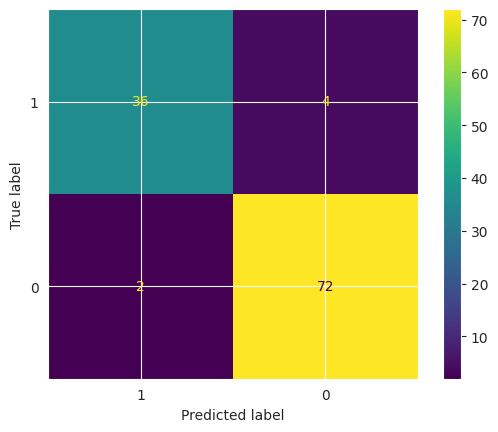

In [43]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size =.2, random_state=41)

X_test = test.iloc[:, :- 1].values
y_test = test. iloc[:,-1].values
y_pred = naive_bayes_gaussian(train, X=X_test, Y="diagnosis")

from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
print('Akurasi =', accuracy_score(y_test, y_pred))
print('F1-Score =', f1_score(y_test, y_pred) )

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

labels = [1, 0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();

